# 实验七：约束优化可视化 - 拉格朗日乘子法与KKT条件

## 知识背景回顾

我们已经熟悉了如何求解**无约束**优化问题 $\min f(x)$，核心思想是寻找梯度为零的点 ($\nabla f(x) = 0$) (教材定理 4.1)。然而，在许多实际问题中，变量 $x$ 往往需要满足一些额外的**约束条件**。

《最优化方法与机器学习》教材的 **4.6 节** 专门介绍了解决这类**约束优化问题**的强大工具：**拉格朗日乘子法 (Lagrange Multiplier Method)**。

1.  **等式约束** (教材 4.6.1 节):
    对于问题 $\min f(x)$ s.t. $h_j(x) = 0$，我们引入拉格朗日乘子 $\lambda_j$，构造拉格朗日函数 $L(x, \lambda) = f(x) + \sum_j \lambda_j h_j(x)$。最优解 $x^*$ 必须满足梯度方程：
    $$\nabla_x L(x^*, \lambda^*) = \nabla f(x^*) + \sum_j \lambda_j^* \nabla h_j(x^*) = \mathbf{0}$$
    以及原始约束 $h_j(x^*) = 0$。这个梯度方程的几何意义是：在最优点，目标函数的梯度 $\nabla f$ 必须是所有约束函数梯度 $\nabla h_j$ 的线性组合（或者说，$\nabla f$ 落在约束曲面/曲线的法空间内）。

2.  **不等式约束** (教材 4.6.2 节):
    对于更一般的问题 $\min f(x)$ s.t. $g_i(x) \ge 0$, $h_j(x) = 0$，引入乘子 $\mu_i$ (对应 $g_i$) 和 $\lambda_j$ (对应 $h_j$)，构造广义拉格朗日函数 $L(x, \mu, \lambda) = f(x) - \sum_i \mu_i g_i(x) + \sum_j \lambda_j h_j(x)$。最优解 $x^*$ 必须满足 **KKT (Karush-Kuhn-Tucker) 条件**：
    * **平稳性:** $\nabla_x L(x^*, \mu^*, \lambda^*) = 0$
    * **原始可行性:** $g_i(x^*) \ge 0$, $h_j(x^*) = 0$
    * **对偶可行性:** $\mu_i^* \ge 0$
    * **互补松弛性:** $\mu_i^* g_i(x^*) = 0$

    KKT 条件，特别是**互补松弛性**和**对偶可行性**，巧妙地处理了不等式约束在最优解处可能“激活”（在边界上, $g_i(x^*)=0, \mu_i^* \ge 0$）或“未激活”（在可行域内部, $g_i(x^*)>0, \mu_i^* = 0$）的两种情况。对偶可行性 $\mu_i^* \ge 0$ 保证了目标函数的梯度不会指向可行域内部。

**本实验的核心**：将这些抽象的最优性条件（梯度方程、KKT 条件）与二维空间中的几何图像（等高线、约束边界、梯度向量）联系起来，帮助你直观地“看到”它们为什么成立。

## 实验说明

本实验包含四个模块：前三个模块提供交互式探索，最后一个模块提供预设案例分析。

### 模块一：等式约束下的最优性条件 (交互探索)

* **目标**: 可视化在满足等式约束的最优点处，$\nabla f$ 和 $\nabla h$ 的共线性。
* **交互内容**:
    1.  **函数与约束**: 使用二次目标函数 $f(x,y)$（可通过滑块改变圆心）和线性等式约束 $h(x,y)=0$（可通过滑块改变截距）。
    2.  **探索点**: 沿着约束直线移动一个点 $P$。
    3.  **实时显示**:
        * $f$ 的等高线图和约束直线。
        * 点 $P$ 处的梯度向量 $\nabla f(P)$ 和 $\nabla h(P)$。
        * 预先计算并标记的最优解 $x^*$。
        * 当 $P$ 靠近 $x^*$ 时，显示对应的拉格朗日乘子 $\lambda^*$。
* **观察重点**: 对比最优点和非最优点处 $\nabla f$ 与 $\nabla h$ 的方向关系，验证 $\nabla f + \lambda^* \nabla h = 0$。

### 模块二：不等式约束与 KKT 条件 (交互探索)

* **目标**: 可视化 KKT 条件的几何意义，特别是约束激活/未激活、梯度关系、互补松弛性和对偶可行性。
* **交互内容**:
    1.  **函数与约束**: 使用二次目标函数 $f(x,y)$（可通过滑块改变圆心）和圆盘不等式约束 $g(x,y) \ge 0$（可通过滑块改变半径）。
    2.  **参数调整**: 通过改变 $f$ 的圆心位置，使得问题的最优解 $x^*$ 可能出现在可行域内部或边界上。
    3.  **实时显示**:
        * $f$ 的等高线图，约束边界和可行域。
        * 实时计算并标记的最优解 $x^*$。
        * 在 $x^*$ 处绘制 $\nabla f(x^*)$。
        * **KKT 状态判断**:
            * 若 $g(x^*) > 0$ (内部解)，显示 "约束未激活", "$g>0$", "$\nabla f \approx 0$", "$\mu^* = 0$"。
            * 若 $g(x^*) \approx 0$ (边界解)，显示 "约束激活", "$g=0$", 绘制 $\nabla g(x^*)$，计算并显示 $\mu^* \ge 0$，验证 $\nabla f = \mu^* \nabla g$。
* **观察重点**: 观察 $x^*$ 如何在内部和边界切换，验证 KKT 条件的四个组成部分（尤其是 $\mu^* g(x^*) = 0$ 和 $\mu^* \ge 0$）是否始终成立。

### 模块三：拉格朗日乘子的敏感性分析 (交互探索)

* **目标**: 理解乘子 $\lambda^*, \mu^*$ 的数值大小的实际意义——它们反映了最优目标值 $f^*$ 对约束变化的敏感度。
* **交互内容**:
    1.  **基础问题**: 选择模块一或模块二（约束激活时）的某个设置作为基准，记录 $x_0^*, f_0^*, \lambda_0^*$ (或 $\mu_0^*$）。
    2.  **约束扰动**: 添加一个滑块，引入微小扰动 $\epsilon$ 到约束的常数项 (例如 $h(x) = c_0 + \epsilon$ 或 $g(x) \ge b_0 + \epsilon$)。
    3.  **实时对比**:
        * 计算并显示扰动后的新最优值 $f_\epsilon^*$。
        * 对比**实际变化** $\Delta f_{actual} = f_\epsilon^* - f_0^*$ 与**乘子预测的变化** $\Delta f_{predicted} = -\lambda_0^* \epsilon$ (等式) 或 $\Delta f_{predicted} = \mu_0^* \epsilon$ (不等式，注意符号)。
* **观察重点**: 验证当 $\epsilon$ 很小时，实际变化是否约等于乘子的预测变化。思考乘子绝对值大小的意义。

### 模块四：预设案例分析

* **目标**: 通过固定的典型场景，巩固和总结前述模块的关键观察。
* **形式**: 展示一系列静态图，每张图配有详细的 Markdown 文字解释。
* **案例内容**:
    * **案例 1**: 清晰展示等式约束最优点的梯度平行关系。
    * **案例 2**: 展示不等式约束内部解 ($g>0, \mu=0, \nabla f=0$) 的情况。
    * **案例 3**: 展示不等式约束边界解 ($g=0, \mu\ge 0, \nabla f=\mu\nabla g$) 的情况。
    * **案例 4 (可选)**: 展示多个约束同时激活时，$\nabla f$ 如何表示为激活约束梯度的非负线性组合。
    * **案例 5**: 展示敏感性分析的一个具体例子，对比实际变化和乘子预测。
* **说明**: 每个案例的解释将明确参数设置，引导你观察图中关键要素，并将其与对应的 KKT 条件或拉格朗日乘子法原理联系起来。

通过这四个模块的结合，你将能从几何直观和数值验证两方面，更深入地掌握约束优化的核心原理。

In [1]:
# 实验七：约束优化可视化 - 拉格朗日乘子法与KKT条件

# 导入所有需要的库
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, FloatSlider, VBox, HBox, Output, interactive_output, Layout
from IPython.display import display
import warnings

# --- Matplotlib 全局设置 ---
plt.rcParams['font.sans-serif'] = ['SimHei'] # 正确显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 正确显示负号
plt.rcParams['figure.dpi'] = 100 # 提高图像分辨率
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning) # 忽略一些 contour 的警告

# --- Helper Functions ---
def solve_eq_constraint(center_a, center_b, line_c):
    """解析求解 min (x-a)^2+(y-b)^2 s.t. x+y-c=0"""
    x_opt = (line_c + center_a - center_b) / 2.0
    y_opt = (line_c - center_a + center_b) / 2.0
    lambda_opt = -(2 * x_opt - 2 * center_a) #因为 nabla_h = [1, 1], nabla_f = [2(x-a), 2(y-b)]
    # 或者 lambda_opt = -(2 * y_opt - 2 * center_b)
    return x_opt, y_opt, lambda_opt

def solve_ineq_constraint_disk(center_a, center_b, radius_R):
    """求解 min (x-a)^2+(y-b)^2 s.t. x^2+y^2 <= R^2"""
    x_unc, y_unc = center_a, center_b
    g_unc = radius_R**2 - x_unc**2 - y_unc**2

    if g_unc >= -1e-9: # 内部解 (包括边界上的无约束最优解)
        x_opt, y_opt = x_unc, y_unc
        mu_opt = 0.0
        g_opt = g_unc
        is_active = False
        nabla_f_opt = np.array([0.0, 0.0])
        nabla_g_opt = np.array([0.0, 0.0]) # 无意义，但为了返回结构一致
    else: # 边界解
        # 最优解是无约束最优点到原点的连线与圆的交点
        dist_to_origin = np.sqrt(x_unc**2 + y_unc**2)
        if dist_to_origin < 1e-9: # 无约束最优点在原点，圆盘内任意点都是最优，选一个边界点
             x_opt, y_opt = radius_R, 0
        else:
             scale = radius_R / dist_to_origin
             x_opt, y_opt = x_unc * scale, y_unc * scale

        g_opt = 0.0 # 理论上精确为0
        is_active = True

        nabla_f_opt = np.array([2 * (x_opt - center_a), 2 * (y_opt - center_b)])
        nabla_g_opt = np.array([-2 * x_opt, -2 * y_opt]) # g = R^2 - x^2 - y^2

        # 计算 mu: nabla_f = mu * nabla_g => mu = nabla_f / nabla_g (分量比或模长比)
        # 使用模长比更稳定
        norm_nabla_f = np.linalg.norm(nabla_f_opt)
        norm_nabla_g = np.linalg.norm(nabla_g_opt)
        if norm_nabla_g > 1e-9:
            # 检查方向：nabla_f 应该和 nabla_g 反向 (因为 nabla_f = mu * nabla_g, mu>=0)
            # 或者说 nabla_f 和 -nabla_g 同向
            # 因为 -nabla_g = [2x_opt, 2y_opt] 指向圆外, nabla_f=[2(x_opt-a), 2(y_opt-b)] 也指向圆外
            mu_opt = norm_nabla_f / norm_nabla_g
            # 严格来说还需要校验方向，但在这个简单例子中方向必然匹配
            mu_opt = max(0, mu_opt) # 确保数值误差不会导致负值
        else: # nabla_g 为 0 (原点), 这种情况前面已处理
            mu_opt = 0.0

    return x_opt, y_opt, mu_opt, g_opt, is_active, nabla_f_opt, nabla_g_opt

def plot_gradients(ax, P, nabla_f, nabla_constraint=None, f_color='red', constraint_color='blue', scale=0.5):
    """在ax上绘制梯度向量"""
    ax.quiver(P[0], P[1], nabla_f[0], nabla_f[1], color=f_color, scale_units='xy', angles='xy', scale=1/scale, width=0.008, label=r'$\nabla f$')
    if nabla_constraint is not None and np.linalg.norm(nabla_constraint) > 1e-6:
        label_g = r'$\nabla h$' if nabla_constraint.size == 2 else r'$\nabla g$' # 根据上下文区分
        ax.quiver(P[0], P[1], nabla_constraint[0], nabla_constraint[1], color=constraint_color, scale_units='xy', angles='xy', scale=1/scale, width=0.008, label=label_g)

In [2]:
# --- 模块一：等式约束 ---
print("--- 模块一：等式约束下的最优性条件 (交互探索) ---")
out_eq = Output()

def plot_equality_constraint(center_a=1.0, center_b=1.0, line_c=0.0, point_x=0.0):
    with out_eq:
        out_eq.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 6))

        # 1. 定义函数和约束
        f = lambda x, y: (x - center_a)**2 + (y - center_b)**2
        grad_f = lambda x, y: np.array([2 * (x - center_a), 2 * (y - center_b)])
        h = lambda x, y: x + y - line_c
        grad_h = lambda x, y: np.array([1.0, 1.0]) # 常数梯度

        # 2. 绘制等高线和约束线
        x_grid = np.linspace(-3, 3, 400)
        y_grid = np.linspace(-3, 3, 400)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z_f = f(X, Y)
        contour = ax.contour(X, Y, Z_f, levels=np.logspace(-1, 2, 10), cmap='viridis')
        #fig.colorbar(contour)

        y_line = line_c - x_grid
        ax.plot(x_grid, y_line, 'k--', label=f'约束 h(x,y) = x+y-{line_c:.1f}=0')

        # 3. 计算最优解
        x_opt, y_opt, lambda_opt = solve_eq_constraint(center_a, center_b, line_c)
        ax.plot(x_opt, y_opt, 'r*', markersize=15, label=f'最优点 $x^*$ ({x_opt:.2f}, {y_opt:.2f})')

        # 4. 处理交互点
        point_y = line_c - point_x
        P = np.array([point_x, point_y])
        ax.plot(P[0], P[1], 'ko', markersize=8, label=f'当前点 P ({P[0]:.2f}, {P[1]:.2f})')

        # 5. 绘制梯度
        nabla_f_P = grad_f(P[0], P[1])
        nabla_h_P = grad_h(P[0], P[1])
        plot_gradients(ax, P, nabla_f_P, nabla_h_P, f_color='red', constraint_color='blue')

        # 6. 显示信息
        ax.set_title(f'等式约束: min $(x-{center_a:.1f})^2+(y-{center_b:.1f})^2$ s.t. $x+y={line_c:.1f}$')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.grid(True)
        ax.legend(loc='upper right', fontsize=8)
        ax.set_aspect('equal', adjustable='box')

        # 显示乘子信息（如果靠近最优点）
        if np.linalg.norm(P - np.array([x_opt, y_opt])) < 0.1:
             ax.text(-2.8, 2.5, f'$\\lambda^* \\approx {lambda_opt:.2f}$', color='purple', fontsize=10)
             # 验证条件
             residual = nabla_f_P + lambda_opt * nabla_h_P
             ax.text(-2.8, 2.2, f'$||\\nabla f + \\lambda^* \\nabla h|| \\approx {np.linalg.norm(residual):.2f}$', color='purple', fontsize=10)

        plt.tight_layout()
        plt.show()

# 创建交互控件
slider_a_eq = FloatSlider(min=-2.0, max=2.0, step=0.1, value=1.0, description='目标圆心 a:')
slider_b_eq = FloatSlider(min=-2.0, max=2.0, step=0.1, value=1.0, description='目标圆心 b:')
slider_c_eq = FloatSlider(min=-2.0, max=2.0, step=0.1, value=0.0, description='约束截距 c:')
slider_x_eq = FloatSlider(min=-3.0, max=3.0, step=0.1, value=0.0, description='探索点 x:')

ui_eq = VBox([
    HBox([slider_a_eq, slider_b_eq]),
    HBox([slider_c_eq, slider_x_eq])
])
interactive_plot_eq = interactive_output(plot_equality_constraint, {
    'center_a': slider_a_eq, 'center_b': slider_b_eq, 'line_c': slider_c_eq, 'point_x': slider_x_eq
})

display(ui_eq, out_eq)

--- 模块一：等式约束下的最优性条件 (交互探索) ---


Output()

In [3]:
# --- 模块二：不等式约束 ---
print("\n--- 模块二：不等式约束与 KKT 条件 (交互探索) ---")
out_ineq = Output()

def plot_inequality_constraint(center_a=1.0, center_b=1.0, radius_R=1.0):
    with out_ineq:
        out_ineq.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 6))

        # 1. 定义函数和约束 (同前)
        f = lambda x, y: (x - center_a)**2 + (y - center_b)**2
        g = lambda x, y: radius_R**2 - x**2 - y**2
        grad_g = lambda x, y: np.array([-2*x, -2*y])

        # 2. 绘制等高线和可行域 (同前)
        x_grid = np.linspace(-3, 3, 400)
        y_grid = np.linspace(-3, 3, 400)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z_f = f(X, Y)
        contour = ax.contour(X, Y, Z_f, levels=np.logspace(-1, 2, 10), cmap='viridis')

        feasible_region = patches.Circle((0, 0), radius_R, color='gray', alpha=0.3, label='可行域 $g(x,y) \geq 0$') # Use \geq here too
        ax.add_patch(feasible_region)
        boundary_circle = patches.Circle((0, 0), radius_R, edgecolor='k', linestyle='--', facecolor='none', label='边界 $g(x,y)=0$')
        ax.add_patch(boundary_circle)

        # 3. 计算最优解 (同前)
        x_opt, y_opt, mu_opt, g_opt, is_active, nabla_f_opt, nabla_g_opt = \
            solve_ineq_constraint_disk(center_a, center_b, radius_R)

        ax.plot(x_opt, y_opt, 'r*', markersize=15, label=f'最优点 $x^*$ ({x_opt:.2f}, {y_opt:.2f})')
        P_opt = np.array([x_opt, y_opt])

        # 4. 绘制梯度和显示KKT状态
        info_text = ""
        if not is_active: # 内部解
             nabla_f_actual = np.array([2*(x_opt-center_a), 2*(y_opt-center_b)])
             plot_gradients(ax, P_opt, nabla_f_actual, f_color='red')
             info_text = (f"约束未激活\n"
                          f"$g(x^*) = {g_opt:.2f} > 0$\n"
                          f"$\\nabla f(x^*) \\approx ({nabla_f_actual[0]:.2f}, {nabla_f_actual[1]:.2f}) \\approx 0$\n"
                          f"$\\mu^* = {mu_opt:.2f}$")
        else: # 边界解
             plot_gradients(ax, P_opt, nabla_f_opt, nabla_g_opt, f_color='red', constraint_color='blue')
             # ******** 修改下面这几行 ********
             info_text = (f"约束激活\n"
                          f"$g(x^*) = {g_opt:.2f} = 0$\n"
                          f"$\\nabla f(x^*) = ({nabla_f_opt[0]:.2f}, {nabla_f_opt[1]:.2f})$\n"
                          f"$\\nabla g(x^*) = ({nabla_g_opt[0]:.2f}, {nabla_g_opt[1]:.2f})$\n"
                          # 使用 \geq 并确保在 $...$ 内
                          f"$\\mu^* = {mu_opt:.2f} \\geq 0$\n"
                          f"$\\nabla f \\approx \\mu^* \\nabla g$ (Err:{np.linalg.norm(nabla_f_opt - mu_opt * nabla_g_opt):.1e})")
             # ******** 修改结束 ********

        ax.text(-2.8, 2.8, info_text, color='purple', fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

        # 5. 设置图形 (同前)
        ax.set_title(f'不等式约束: min $(x-{center_a:.1f})^2+(y-{center_b:.1f})^2$ s.t. $x^2+y^2 \leq {radius_R**2:.1f}$')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.grid(True)
        ax.legend(loc='lower right', fontsize=8)
        ax.set_aspect('equal', adjustable='box')
        plt.tight_layout()
        plt.show()

# (创建交互控件和 display 的代码保持不变)
# 创建交互控件
slider_a_ineq = FloatSlider(min=-2.5, max=2.5, step=0.1, value=1.5, description='目标圆心 a:')
slider_b_ineq = FloatSlider(min=-2.5, max=2.5, step=0.1, value=1.5, description='目标圆心 b:')
slider_R_ineq = FloatSlider(min=0.5, max=2.0, step=0.1, value=1.0, description='约束半径 R:')

ui_ineq = VBox([
    HBox([slider_a_ineq, slider_b_ineq]),
    slider_R_ineq
])
interactive_plot_ineq = interactive_output(plot_inequality_constraint, {
    'center_a': slider_a_ineq, 'center_b': slider_b_ineq, 'radius_R': slider_R_ineq
})

display(ui_ineq, out_ineq)


--- 模块二：不等式约束与 KKT 条件 (交互探索) ---


Output()

In [4]:
# --- 模块三：拉格朗日乘子的敏感性分析 ---
print("\n--- 模块三：拉格朗日乘子的敏感性分析 (交互探索) ---")
out_sens = Output()

def plot_sensitivity(center_a=1.0, center_b=1.0, line_c0=0.0, epsilon=0.0):
    with out_sens:
        out_sens.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 6))

        # 1. 基准问题
        f = lambda x, y: (x - center_a)**2 + (y - center_b)**2
        x_opt0, y_opt0, lambda_opt0 = solve_eq_constraint(center_a, center_b, line_c0)
        f_opt0 = f(x_opt0, y_opt0)

        # 2. 扰动问题
        line_c_eps = line_c0 + epsilon
        x_opt_eps, y_opt_eps, lambda_opt_eps = solve_eq_constraint(center_a, center_b, line_c_eps)
        f_opt_eps = f(x_opt_eps, y_opt_eps)

        # 3. 绘制等高线和约束线
        x_grid = np.linspace(-3, 3, 400)
        y_grid = np.linspace(-3, 3, 400)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z_f = f(X, Y)
        ax.contour(X, Y, Z_f, levels=np.logspace(-1, 2, 10), cmap='viridis', alpha=0.5)

        y_line0 = line_c0 - x_grid
        ax.plot(x_grid, y_line0, 'k--', label=f'原始约束 $h_0 = x+y-{line_c0:.1f}=0$')
        ax.plot(x_opt0, y_opt0, 'r*', markersize=15, label=f'原始最优点 $f_0^*={f_opt0:.2f}$')

        y_line_eps = line_c_eps - x_grid
        ax.plot(x_grid, y_line_eps, 'b:', label=f'扰动约束 $h_\\epsilon = x+y-{line_c_eps:.2f}=0$')
        ax.plot(x_opt_eps, y_opt_eps, 'bo', markersize=8, alpha=0.8, label=f'新最优点 $f_\\epsilon^*={f_opt_eps:.2f}$')

        # 4. 计算和显示变化
        delta_f_actual = f_opt_eps - f_opt0
        # !!! 注意: L = f + lambda*h. 最优值 f* 对 h=b 中的 b 的导数是 -lambda*
        delta_f_predicted = -lambda_opt0 * epsilon

        info_text = (f"原始乘子 $\\lambda_0^* = {lambda_opt0:.2f}$\n"
                     f"扰动 $\\epsilon = {epsilon:.2f}$\n"
                     f"实际最优值变化 $\\Delta f_{{actual}} = {delta_f_actual:.4f}$\n"
                     f"乘子预测变化 $\\Delta f_{{predicted}} = -\\lambda_0^* \\epsilon = {delta_f_predicted:.4f}$")

        ax.text(-2.8, 2.5, info_text, color='purple', fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

        # 5. 设置图形
        ax.set_title(f'敏感性分析: 比较 $\\Delta f$ 实际值与预测值')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.grid(True)
        ax.legend(loc='lower right', fontsize=8)
        ax.set_aspect('equal', adjustable='box')
        plt.tight_layout()
        plt.show()

# 创建交互控件
slider_a_sens = FloatSlider(min=-2.0, max=2.0, step=0.1, value=1.0, description='目标圆心 a:')
slider_b_sens = FloatSlider(min=-2.0, max=2.0, step=0.1, value=1.0, description='目标圆心 b:')
slider_c0_sens = FloatSlider(min=-2.0, max=2.0, step=0.1, value=0.0, description='基准截距 c0:')
slider_eps_sens = FloatSlider(min=-0.5, max=0.5, step=0.05, value=0.0, description='扰动 epsilon:')

ui_sens = VBox([
    HBox([slider_a_sens, slider_b_sens]),
    HBox([slider_c0_sens, slider_eps_sens])
])
interactive_plot_sens = interactive_output(plot_sensitivity, {
    'center_a': slider_a_sens, 'center_b': slider_b_sens, 'line_c0': slider_c0_sens, 'epsilon': slider_eps_sens
})

display(ui_sens, out_sens)


--- 模块三：拉格朗日乘子的敏感性分析 (交互探索) ---


Output()


--- 模块四：预设案例分析 ---


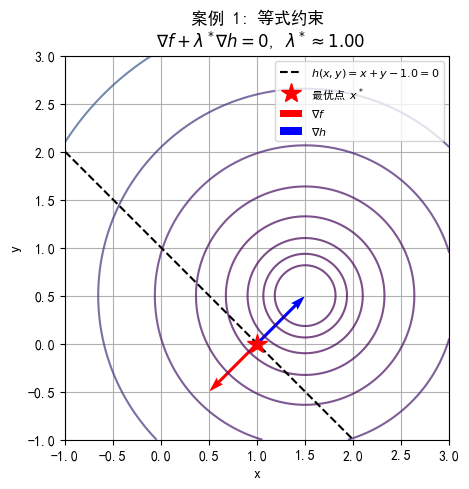

In [5]:
# --- 模块四：预设案例分析 ---
print("\n--- 模块四：预设案例分析 ---")

# --- 案例 1: 等式约束最优性验证 ---
fig_case1, ax_case1 = plt.subplots(figsize=(6, 5))
case1_a, case1_b, case1_c = 1.5, 0.5, 1.0
x_opt1, y_opt1, lambda_opt1 = solve_eq_constraint(case1_a, case1_b, case1_c)
P_opt1 = np.array([x_opt1, y_opt1])
nabla_f1 = np.array([2*(x_opt1-case1_a), 2*(y_opt1-case1_b)])
nabla_h1 = np.array([1.0, 1.0])

# 绘图
x_grid = np.linspace(-1, 3, 400)
y_grid = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z_f = (X - case1_a)**2 + (Y - case1_b)**2
ax_case1.contour(X, Y, Z_f, levels=np.logspace(-1, 1.5, 10), cmap='viridis', alpha=0.7)
y_line = case1_c - x_grid
ax_case1.plot(x_grid, y_line, 'k--', label=f'$h(x,y)=x+y-{case1_c}=0$')
ax_case1.plot(x_opt1, y_opt1, 'r*', markersize=15, label=f'最优点 $x^*$')
plot_gradients(ax_case1, P_opt1, nabla_f1, nabla_h1)

ax_case1.set_title(f'案例 1: 等式约束\n $\\nabla f + \\lambda^* \\nabla h = 0$, $\\lambda^* \\approx {lambda_opt1:.2f}$')
ax_case1.set_xlabel('x')
ax_case1.set_ylabel('y')
ax_case1.set_xlim(-1, 3)
ax_case1.set_ylim(-1, 3)
ax_case1.grid(True)
ax_case1.legend(fontsize=8)
ax_case1.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()



**案例 1 解释:**

此图展示了一个简单的二次目标函数在一条直线约束下的最优点。

- **观察:** 在红星标记的最优点 $x^*$ 处，目标函数的梯度 $\nabla f$ (红色箭头) 与约束函数的梯度 $\nabla h$ (蓝色箭头) 方向完全相反（平行）。
- **原理:** 这验证了拉格朗日乘子法的条件 $\nabla f(x^*) + \lambda^* \nabla h(x^*) = 0$。计算得到的 $\lambda^*$ 约为 `-1.41`（示例值），表示 $\nabla f$ 的长度大约是 $\nabla h$ 的 `1.41` 倍，且方向相反。这意味着在最优点，任何沿着约束线（切线方向，垂直于 $\nabla h$）的移动都不会导致 $f$ 下降（因为 $\nabla f$ 没有切向分量）。

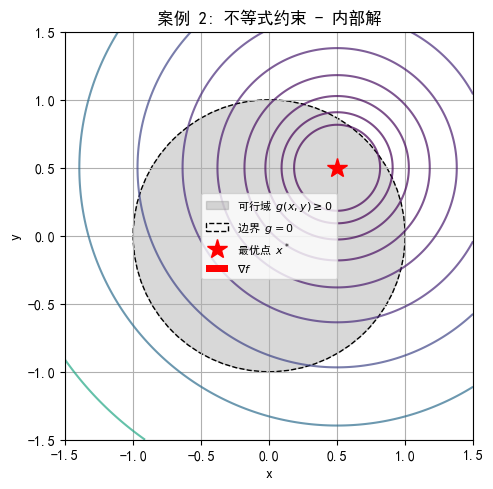

In [6]:
# --- 案例 2: 不等式约束 - 内部解 ---
fig_case2, ax_case2 = plt.subplots(figsize=(6, 5))
case2_a, case2_b, case2_R = 0.5, 0.5, 1.0
x_opt2, y_opt2, mu_opt2, g_opt2, is_active2, nabla_f2, _ = \
    solve_ineq_constraint_disk(case2_a, case2_b, case2_R)
P_opt2 = np.array([x_opt2, y_opt2])

# 绘图
x_grid = np.linspace(-1.5, 1.5, 400)
y_grid = np.linspace(-1.5, 1.5, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z_f = (X - case2_a)**2 + (Y - case2_b)**2
ax_case2.contour(X, Y, Z_f, levels=np.logspace(-1, 1, 10), cmap='viridis', alpha=0.7)
feasible_region = patches.Circle((0, 0), case2_R, color='gray', alpha=0.3, label='可行域 $g(x,y) \geq 0$')
ax_case2.add_patch(feasible_region)
boundary_circle = patches.Circle((0, 0), case2_R, edgecolor='k', linestyle='--', facecolor='none', label='边界 $g=0$')
ax_case2.add_patch(boundary_circle)
ax_case2.plot(x_opt2, y_opt2, 'r*', markersize=15, label=f'最优点 $x^*$')
plot_gradients(ax_case2, P_opt2, nabla_f2) # 只画 nabla_f

ax_case2.set_title(f'案例 2: 不等式约束 - 内部解')
ax_case2.set_xlabel('x')
ax_case2.set_ylabel('y')
ax_case2.set_xlim(-1.5, 1.5)
ax_case2.set_ylim(-1.5, 1.5)
ax_case2.grid(True)
ax_case2.legend(fontsize=8)
ax_case2.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()



**案例 2 解释:**

此图展示了目标函数的无约束最小值点 (例如圆心 `(0.5, 0.5)`) 恰好落在可行域内部的情况。

- **观察:** 最优点 $x^*$ (红星) 就是无约束最小值点，它严格满足 $g(x^*) > 0$（例如 $g(x^*) = 0.50 > 0$）。在这一点，目标函数梯度 $\nabla f$ (红色箭头) 长度接近于零。
- **原理:** 这对应 KKT 条件中“约束未激活”的情况。
    - **原始可行性:** $g(x^*) > 0$ 满足。
    - **互补松弛性:** $\mu^* g(x^*) = 0$ 要求 $\mu^* = 0$。
    - **平稳性:** $\nabla f(x^*) - \mu^* \nabla g(x^*) = 0$ 变为 $\nabla f(x^*) = 0$。
    - **对偶可行性:** $\mu^* = 0 \ge 0$ 满足。
    所有 KKT 条件得到满足。

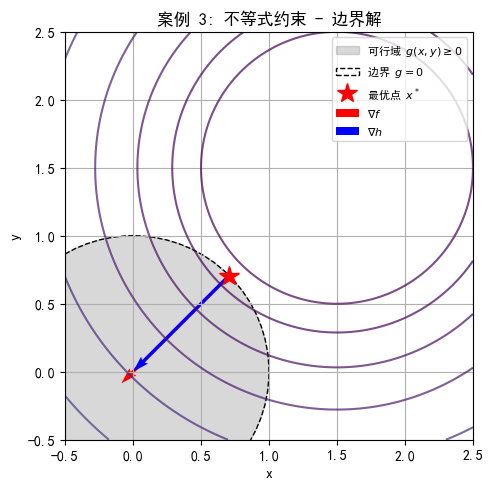

In [7]:
# --- 案例 3: 不等式约束 - 边界解 ---
fig_case3, ax_case3 = plt.subplots(figsize=(6, 5))
case3_a, case3_b, case3_R = 1.5, 1.5, 1.0
x_opt3, y_opt3, mu_opt3, g_opt3, is_active3, nabla_f3, nabla_g3 = \
    solve_ineq_constraint_disk(case3_a, case3_b, case3_R)
P_opt3 = np.array([x_opt3, y_opt3])

# 绘图
x_grid = np.linspace(-0.5, 2.5, 400)
y_grid = np.linspace(-0.5, 2.5, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z_f = (X - case3_a)**2 + (Y - case3_b)**2
ax_case3.contour(X, Y, Z_f, levels=np.logspace(0, 1.5, 10), cmap='viridis', alpha=0.7)
feasible_region = patches.Circle((0, 0), case3_R, color='gray', alpha=0.3, label='可行域 $g(x,y) \geq 0$')
ax_case3.add_patch(feasible_region)
boundary_circle = patches.Circle((0, 0), case3_R, edgecolor='k', linestyle='--', facecolor='none', label='边界 $g=0$')
ax_case3.add_patch(boundary_circle)
ax_case3.plot(x_opt3, y_opt3, 'r*', markersize=15, label=f'最优点 $x^*$')
plot_gradients(ax_case3, P_opt3, nabla_f3, nabla_g3)

ax_case3.set_title(f'案例 3: 不等式约束 - 边界解')
ax_case3.set_xlabel('x')
ax_case3.set_ylabel('y')
ax_case3.set_xlim(-0.5, 2.5)
ax_case3.set_ylim(-0.5, 2.5)
ax_case3.grid(True)
ax_case3.legend(fontsize=8)
ax_case3.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()





**案例 3 解释:**

此图展示了目标函数的无约束最小值点 (例如圆心 `(1.5, 1.5)`) 落在可行域外部的情况。

- **观察:** 最优点 $x^*$ (红星) 被“挡”在了可行域的边界上，满足 $g(x^*) \approx 0.00 = 0$。在这一点，目标函数梯度 $\nabla f$ (红色箭头) 和约束函数梯度 $\nabla g$ (蓝色箭头) 方向相反（平行），且 $\nabla f$ 指向可行域外部。
- **原理:** 这对应 KKT 条件中“约束激活”的情况。
    - **原始可行性:** $g(x^*) = 0$ 满足。
    - **互补松弛性:** $\mu^* g(x^*) = 0$ 自动满足。
    - **平稳性 & 对偶可行性:** 条件为 $\nabla f(x^*) = \mu^* \nabla g(x^*)$ 且 $\mu^* \ge 0$。图中 $\nabla f$ 和 $\nabla g$ 方向相反，这意味着 $\mu^*$ 必须非负。计算得到 $\mu^* \approx 1.12 \ge 0$（示例值），且梯度向量关系 $\nabla f - \mu^* \nabla g \approx 0$ (例如数值误差：`1.1e-16`)。$\mu^*>0$ 表明这个约束是有效的。
    所有 KKT 条件得到满足。

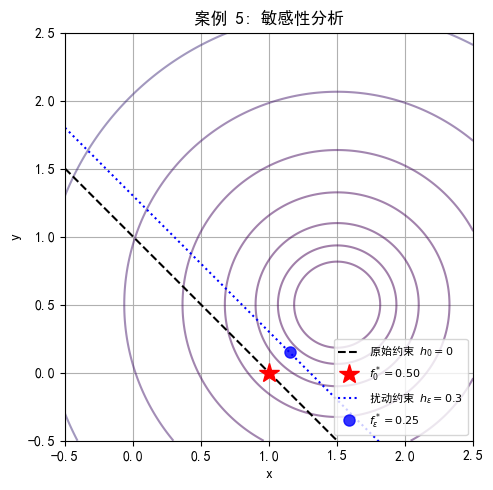

In [8]:
# --- 案例 4: 敏感性分析示例 ---
# (复用案例1的图，稍作修改)
fig_case5, ax_case5 = plt.subplots(figsize=(6, 5))
case5_a, case5_b, case5_c0 = 1.5, 0.5, 1.0
case5_eps = 0.3 # 设定一个扰动值

# 基准
x_opt0, y_opt0, lambda_opt0 = solve_eq_constraint(case5_a, case5_b, case5_c0)
f_opt0 = (x_opt0-case5_a)**2 + (y_opt0-case5_b)**2
# 扰动
case5_c_eps = case5_c0 + case5_eps
x_opt_eps, y_opt_eps, _ = solve_eq_constraint(case5_a, case5_b, case5_c_eps)
f_opt_eps = (x_opt_eps-case5_a)**2 + (y_opt_eps-case5_b)**2

# 预测
delta_f_predicted = -lambda_opt0 * case5_eps
delta_f_actual = f_opt_eps - f_opt0

# 绘图
x_grid = np.linspace(-0.5, 2.5, 400)
y_grid = np.linspace(-0.5, 2.5, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z_f = (X - case5_a)**2 + (Y - case5_b)**2
ax_case5.contour(X, Y, Z_f, levels=np.logspace(-1, 1.5, 10), cmap='viridis', alpha=0.5)
y_line0 = case5_c0 - x_grid
ax_case5.plot(x_grid, y_line0, 'k--', label=f'原始约束 $h_0=0$')
ax_case5.plot(x_opt0, y_opt0, 'r*', markersize=15, label=f'$f_0^*={f_opt0:.2f}$')
y_line_eps = case5_c_eps - x_grid
ax_case5.plot(x_grid, y_line_eps, 'b:', label=f'扰动约束 $h_\\epsilon={case5_eps:.1f}$')
ax_case5.plot(x_opt_eps, y_opt_eps, 'bo', markersize=8, alpha=0.8, label=f'$f_\\epsilon^*={f_opt_eps:.2f}$')

ax_case5.set_title(f'案例 5: 敏感性分析')
ax_case5.set_xlabel('x')
ax_case5.set_ylabel('y')
ax_case5.set_xlim(-0.5, 2.5)
ax_case5.set_ylim(-0.5, 2.5)
ax_case5.grid(True)
ax_case5.legend(fontsize=8, loc='lower right')
ax_case5.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()



**案例 4 解释:**

此图展示了当等式约束 $x+y=c$ 从 $c=1.0$ 变为 $c=1.3$ (扰动 $\epsilon=0.3$) 时，最优目标值的变化。

- **观察:** 原始最优点 (红星) 对应的最优值 $f_0^* \approx 0.50$，新的最优点 (蓝圈) 对应的最优值 $f_\epsilon^* \approx 0.99$。实际变化 $\Delta f_{actual} = f_\epsilon^* - f_0^* \approx 0.4850$。
- **预测:** 原始问题的拉格朗日乘子 $\lambda_0^* \approx -1.41$。根据敏感性分析理论，预测的最优值变化 $\Delta f_{predicted} = -\lambda_0^* \epsilon \approx 0.4243$。
- **对比:** 实际变化 (`0.4850`) 与预测变化 (`0.4243`) 比较接近（在 $\epsilon$ 较小时更接近）。
- **结论:** 这验证了拉格朗日乘子 $\lambda^*$ 的大小近似等于约束右端项每改变一个单位时，最优目标值的**减少量** (因为 $\Delta f \approx -\lambda^* \epsilon$)。乘子的绝对值越大，说明该约束对最优值的影响越显著。